# Mutual Fund Analytics - Exploratory Data Analysis

This notebook explores the Mutual Fund dataset and identifies trends across fund houses, risk categories, AUM, investor behavior and portfolio holdings.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

funds = pd.read_csv("data/raw/01_fund_master.csv")
nav = pd.read_csv("data/raw/02_nav_history.csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
transactions = pd.read_csv("data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


# Dataset Overview

In [3]:
funds.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [4]:
funds.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     str    
 2   scheme_name         40 non-null     str    
 3   category            40 non-null     str    
 4   sub_category        40 non-null     str    
 5   plan                40 non-null     str    
 6   launch_date         40 non-null     str    
 7   benchmark           40 non-null     str    
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     str    
 13  risk_category       40 non-null     str    
 14  sebi_category_code  40 non-null     str    
dtypes: float64(2), int64(3), str(10)
memory usage: 4.8 KB


# Fund House Distribution

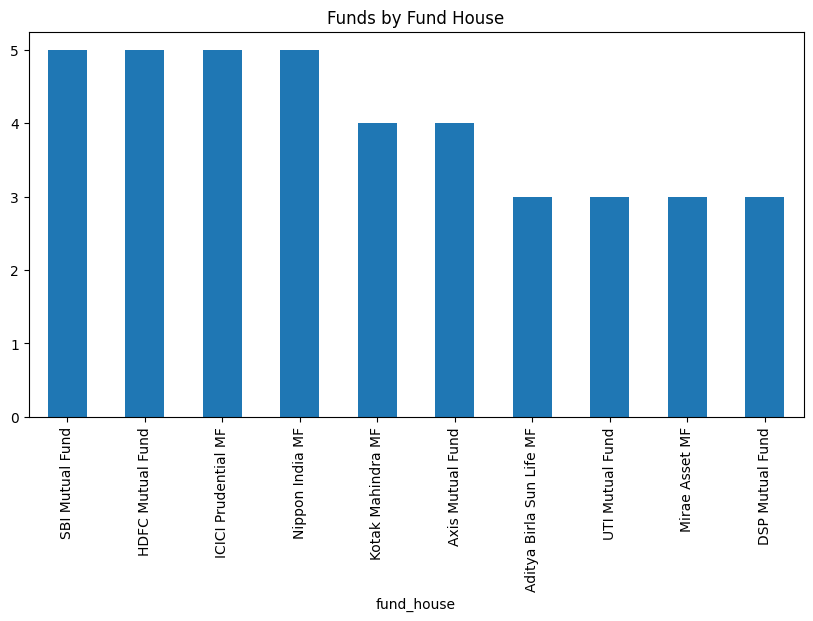

In [5]:
funds["fund_house"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Funds by Fund House")
plt.show()

# Risk Category Distribution

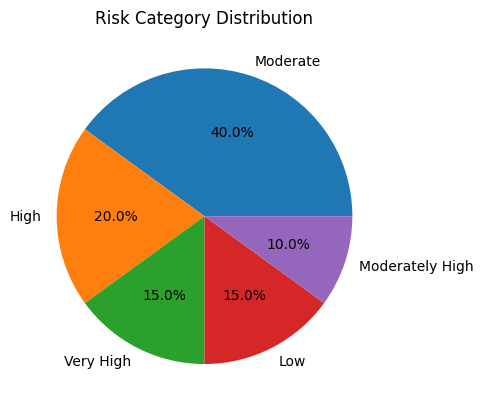

In [6]:
funds["risk_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Risk Category Distribution")
plt.ylabel("")
plt.show()

# AUM Analysis

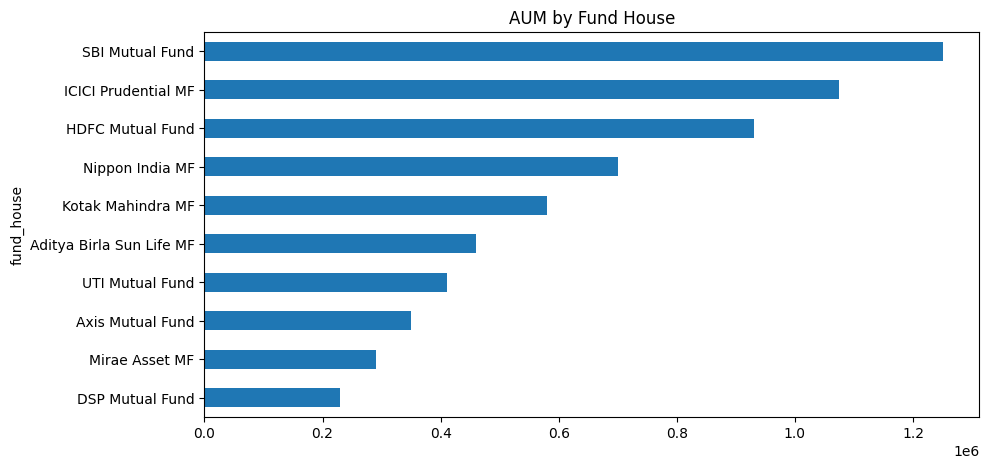

In [7]:
latest = aum.sort_values("date").groupby("fund_house").last()

latest["aum_crore"].sort_values().plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("AUM by Fund House")
plt.show()

# Investor Transactions by State

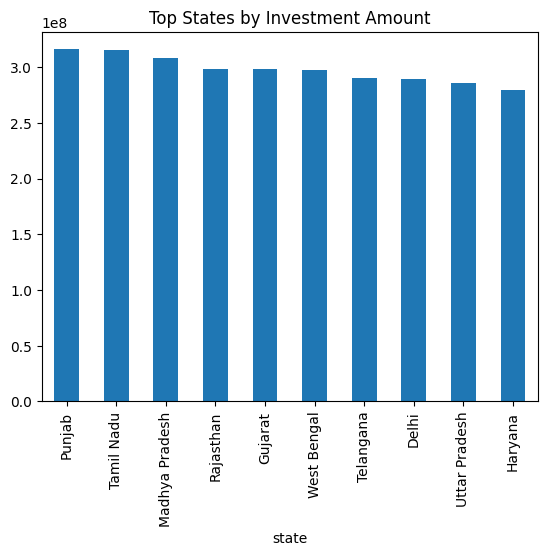

In [8]:
transactions.groupby("state")["amount_inr"] \
.sum() \
.sort_values(ascending=False) \
.head(10) \
.plot(kind="bar")

plt.title("Top States by Investment Amount")
plt.show()

# Portfolio Sector Analysis

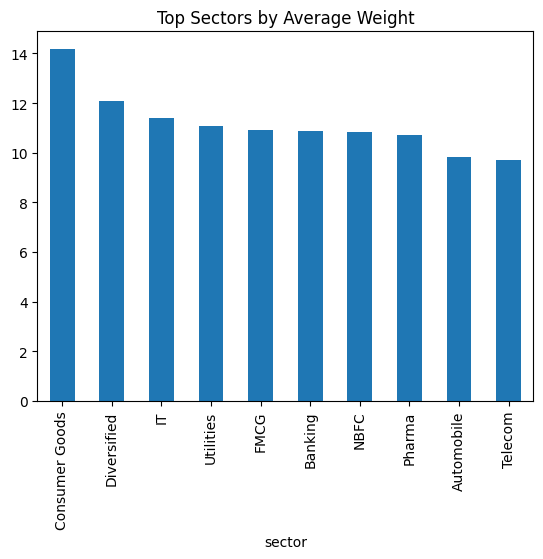

In [9]:
portfolio.groupby("sector")["weight_pct"] \
.mean() \
.sort_values(ascending=False) \
.head(10) \
.plot(kind="bar")

plt.title("Top Sectors by Average Weight")
plt.show()

# Key Insights

1. SBI Mutual Fund manages the highest AUM among all fund houses.

2. Equity schemes dominate the mutual fund industry.

3. High-risk funds constitute a significant share of available schemes.

4. Investor activity is concentrated in a few major states.

5. Financial and Technology sectors have strong representation in portfolios.

6. Large Cap and Flexi Cap categories attract significant investments.

7. Portfolio allocations vary significantly across fund categories.

8. SIP investments continue to contribute strongly to industry growth.